## RQ4: Econometric Analysis — Behavioral Associations with Profit Erosion

**Research Question**: What are the marginal associations between customer behaviors and profit erosion?

**Method**: OLS regression with HC3 robust standard errors. Primary specification is log-linear
(appropriate for a strictly positive, right-skewed monetary outcome). Linear OLS is reported as
a robustness check.

**Hypothesis (H₀₄)**: None of the behavioral predictors have a statistically significant marginal
association with profit erosion (all β = 0).

**Hypothesis predictors**: `return_frequency`, `avg_basket_size`, `purchase_recency_days`

**Decision rule**: Reject H₀ if any hypothesis predictor is statistically significant (p < 0.05)
after controlling for behavioral controls and demographics.

In [14]:
import time
from contextlib import contextmanager

_timings = {}  # label -> elapsed seconds
pipeline_start = time.perf_counter()

@contextmanager
def timer(label):
    start = time.perf_counter()
    yield
    elapsed = time.perf_counter() - start
    _timings[label] = elapsed
    print(f"  [{label}] {elapsed:.1f}s")

In [15]:
# ─── 8.0 RQ4 Module Setup ────────────────────────────────────────────────────
import sys
import os
from pathlib import Path

# Add project root to path (works in Jupyter notebooks)
project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import importlib
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

rq4_modules = [
    "src.rq4_econometrics",
    "src.rq4_visuals",
    "src.rq4_validation",
]
for mod in rq4_modules:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from src.rq4_econometrics import (
    load_rq4_data,
    screen_features,
    prepare_regression_data,
    fit_ols_robust,
    extract_coefficient_table,
    calculate_vif,
)
from src.rq4_visuals import (
    plot_target_distribution,
    plot_coefficient_forest,
    plot_residual_diagnostics,
    plot_qq_comparison,
)
from src.rq4_validation import (
    create_ssl_regression_target,
    engineer_ssl_regression_features,
    validate_coefficient_alignment,
    validate_directional_effect_sizes,
    build_validation_summary,
)
from src.rq3_validation import load_ssl_data, engineer_ssl_account_features
from src.config import (
    RQ4_TARGET_COL,
    RQ4_HYPOTHESIS_PREDICTORS,
    RQ4_BEHAVIORAL_CONTROLS,
    RQ4_ALPHA,
    RQ4_COLLINEARITY_THRESHOLD,
    REPORTS_DIR,
    FIGURES_DIR,
)

rq4_reports = REPORTS_DIR / "rq4"
rq4_figs    = FIGURES_DIR  / "rq4"
rq4_reports.mkdir(parents=True, exist_ok=True)
rq4_figs.mkdir(parents=True, exist_ok=True)

print("RQ4 modules loaded.")
print(f"  Hypothesis predictors : {RQ4_HYPOTHESIS_PREDICTORS}")
print(f"  Behavioral controls   : {RQ4_BEHAVIORAL_CONTROLS}")
print(f"  Target                : {RQ4_TARGET_COL}")

RQ4 modules loaded.
  Hypothesis predictors : ['return_frequency', 'avg_basket_size', 'purchase_recency_days']
  Behavioral controls   : ['order_frequency', 'avg_order_value', 'customer_tenure_days', 'customer_return_rate', 'age']
  Target                : total_profit_erosion


In [16]:
# ─── 8.1 Load Data & Feature Screening ───────────────────────────────────────
with timer("8.1 RQ4 Data Load & Screening"):
    thelook_df = load_rq4_data()

print(f"TheLook dataset: {len(thelook_df):,} customers, {thelook_df.shape[1]} columns")
print(f"Target mean: ${thelook_df[RQ4_TARGET_COL].mean():,.2f}  std: ${thelook_df[RQ4_TARGET_COL].std():,.2f}")

# Feature screening: 3-gate pipeline (variance, collinearity, ANOVA)
with timer("8.1 RQ4 Feature Screening"):
    rq4_screen = screen_features(
        thelook_df, RQ4_TARGET_COL,
        alpha=RQ4_ALPHA,
        collinearity_threshold=RQ4_COLLINEARITY_THRESHOLD,
    )

rq4_surviving     = rq4_screen["surviving_numeric"]
rq4_categorical   = rq4_screen["surviving_categorical"]
rq4_hyp_survivors = [f for f in RQ4_HYPOTHESIS_PREDICTORS if f in rq4_surviving]
rq4_ctrl_survivors= [f for f in RQ4_BEHAVIORAL_CONTROLS   if f in rq4_surviving]

print(f"\nSurviving numeric features ({len(rq4_surviving)}): {rq4_surviving}")
print(f"Collinearity dropped              : {rq4_screen['collinearity_dropped']}")
print(f"Surviving categorical             : {rq4_categorical}")

  [8.1 RQ4 Data Load & Screening] 3.1s
TheLook dataset: 11,988 customers, 23 columns
Target mean: $68.11  std: $60.02
  [8.1 RQ4 Feature Screening] 0.1s

Surviving numeric features (7): ['age', 'avg_basket_size', 'avg_order_value', 'customer_return_rate', 'customer_tenure_days', 'purchase_recency_days', 'return_frequency']
Collinearity dropped              : ['order_frequency']
Surviving categorical             : ['user_gender', 'dominant_return_category']


In [17]:
# ─── 8.2 Prepare Data & Fit OLS (Log-Linear Primary + Linear Robustness) ─────
with timer("8.2 RQ4 OLS Fit"):
    # Log-linear (primary)
    rq4_reg_data = prepare_regression_data(
        thelook_df,
        target_col=RQ4_TARGET_COL,
        numeric_features=rq4_surviving,
        categorical_features=rq4_categorical,
        log_transform=True,
    )
    rq4_log_target = f"log_{RQ4_TARGET_COL}"
    rq4_reg_log = rq4_reg_data.drop(columns=[RQ4_TARGET_COL])
    rq4_results_log = fit_ols_robust(rq4_reg_log, rq4_log_target)

    # Linear (robustness check)
    rq4_reg_lin = rq4_reg_data.drop(columns=[rq4_log_target])
    rq4_results_lin = fit_ols_robust(rq4_reg_lin, RQ4_TARGET_COL)

print("PRIMARY: Log-Linear OLS (HC3 robust SE)")
print(f"  R\u00b2         : {rq4_results_log.rsquared:.4f}")
print(f"  Adj R\u00b2     : {rq4_results_log.rsquared_adj:.4f}")
print(f"  F-stat     : {rq4_results_log.fvalue:.2f}  (p < {rq4_results_log.f_pvalue:.2e})")
print(f"  Obs        : {int(rq4_results_log.nobs):,}")

rq4_coef_log = extract_coefficient_table(rq4_results_log)
print("\nHypothesis predictors (log-linear):")
hyp_rows = rq4_coef_log[rq4_coef_log["feature"].isin(RQ4_HYPOTHESIS_PREDICTORS)]
for _, row in hyp_rows.iterrows():
    pct = (np.exp(row["coefficient"]) - 1) * 100
    sig = "***" if row["p_value"] < 0.001 else ("**" if row["p_value"] < 0.01 else ("*" if row["p_value"] < 0.05 else "n.s."))
    print(f"  {row['feature']:<28} log_b={row['coefficient']:+.4f}  ({pct:+.1f}%)  p={row['p_value']:.4f} {sig}")

print("\nROBUSTNESS: Linear OLS (standardised target, HC3)")
print(f"  R\u00b2         : {rq4_results_lin.rsquared:.4f}")

  [8.2 RQ4 OLS Fit] 0.1s
PRIMARY: Log-Linear OLS (HC3 robust SE)
  R²         : 0.7765
  Adj R²     : 0.7759
  F-stat     : 875.20  (p < 0.00e+00)
  Obs        : 11,694

Hypothesis predictors (log-linear):
  return_frequency             log_b=+0.4454  (+56.1%)  p=0.0000 ***
  avg_basket_size              log_b=-0.1559  (-14.4%)  p=0.0000 ***
  purchase_recency_days        log_b=-0.0009  (-0.1%)  p=0.8242 n.s.

ROBUSTNESS: Linear OLS (standardised target, HC3)
  R²         : 0.8082


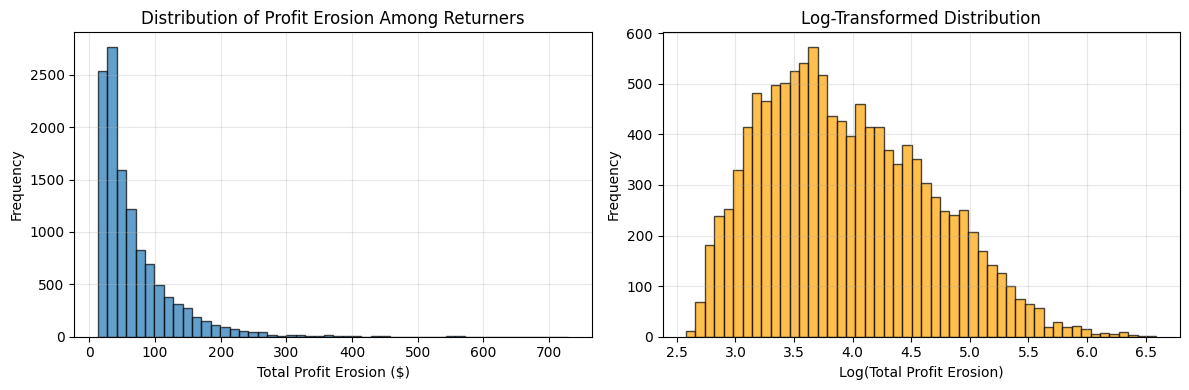

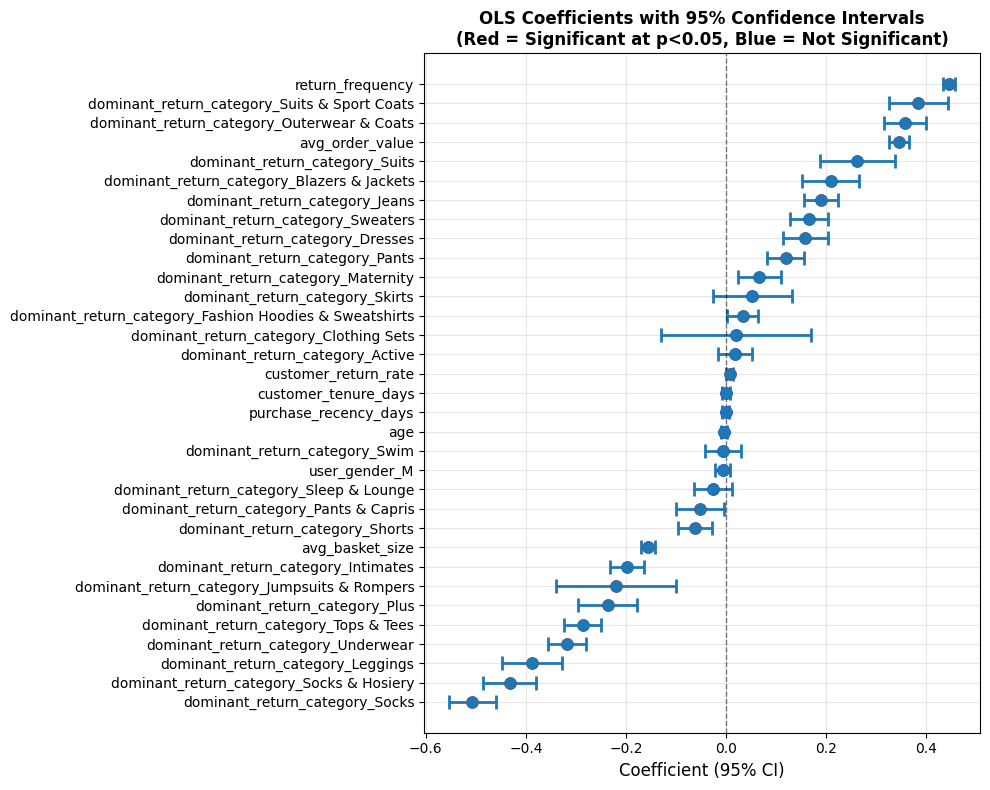

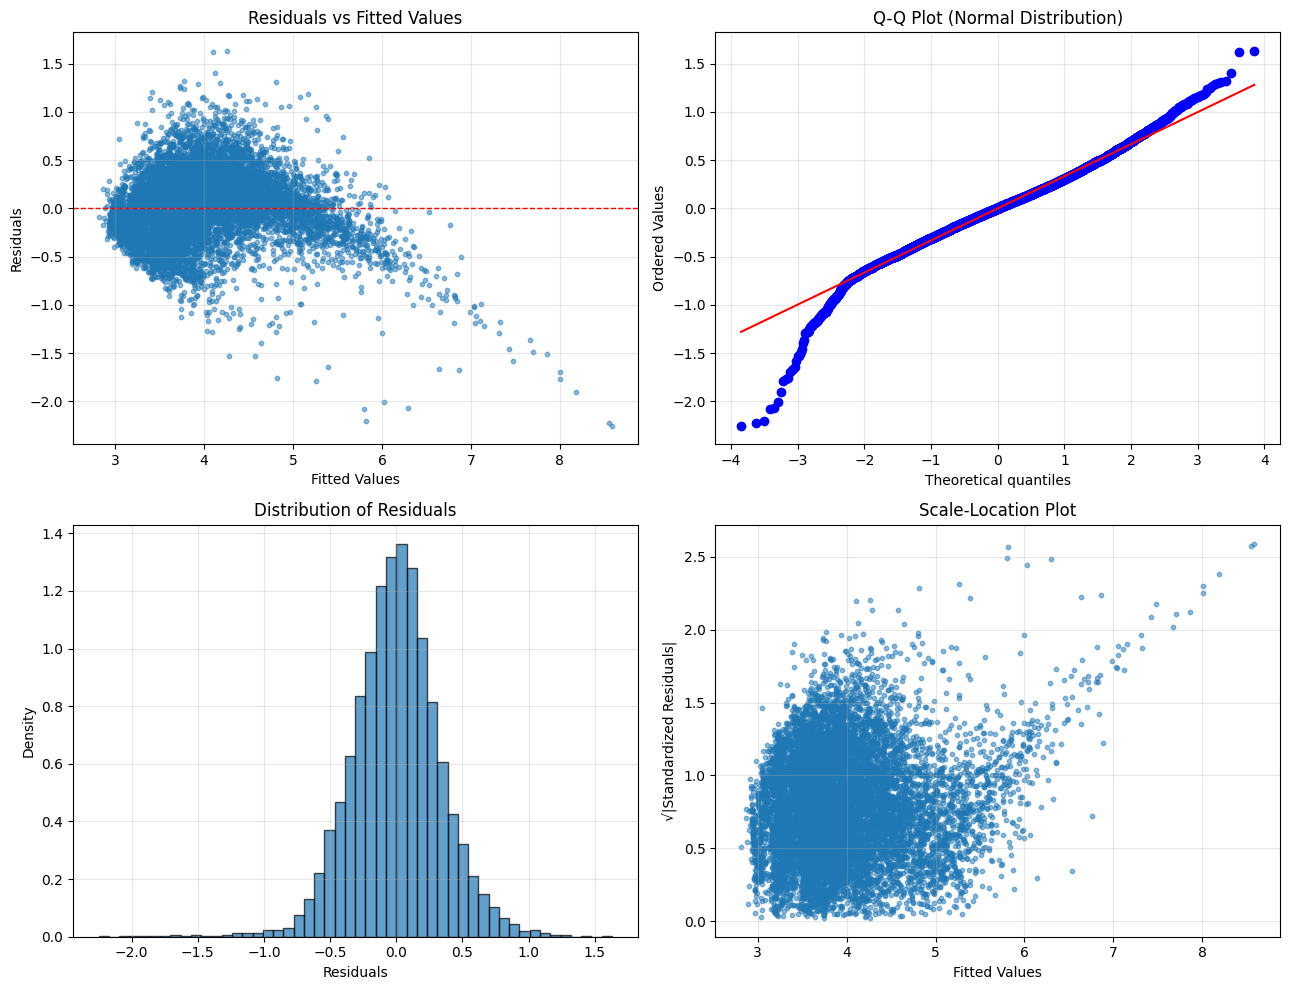

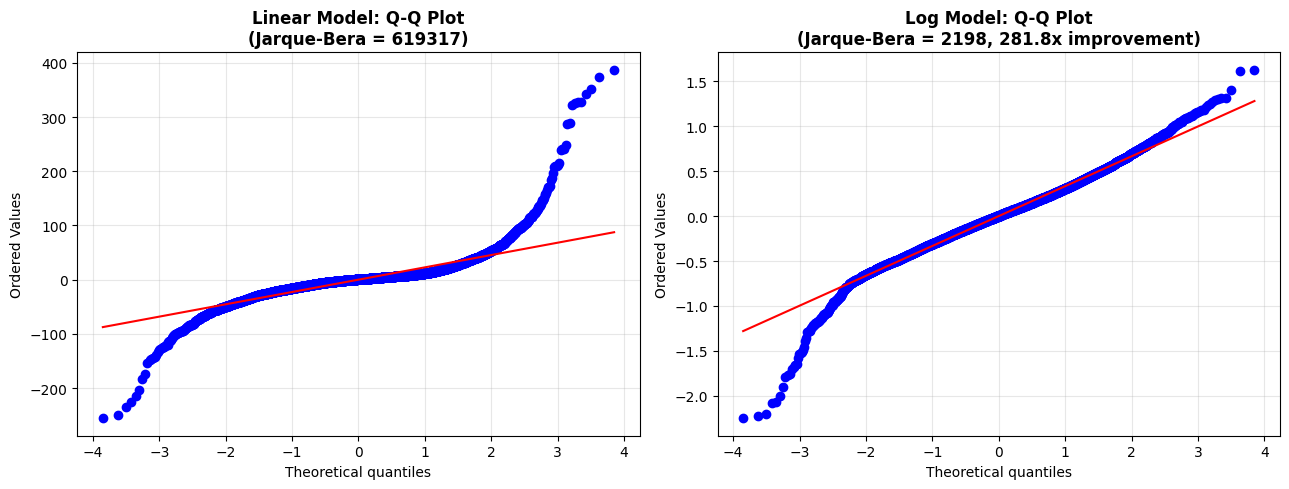

Figures saved to figures/rq4/
  [8.3 RQ4 Diagnostics] 4.5s


In [18]:
# ─── 8.3 Diagnostics & Visualizations ────────────────────────────────────────
with timer("8.3 RQ4 Diagnostics"):
    try:
        from statsmodels.stats.stattools import jarque_bera as _jb
        import numpy as np

        # Target distribution
        fig_tgt = plot_target_distribution(thelook_df, rq4_figs)
        plt.show()
        plt.close(fig_tgt)

        # Coefficient forest plot
        # plot_coefficient_forest expects: 'Feature', 'Coefficient', 'p-value',
        # '95% CI Lower', '95% CI Upper' -- rename from extract_coefficient_table output
        rq4_coef_log_full = extract_coefficient_table(rq4_results_log)
        rq4_coef_for_plot = rq4_coef_log_full.rename(columns={
            "feature":    "Feature",
            "coefficient":"Coefficient",
            "p_value":    "p-value",
            "ci_lower":   "95% CI Lower",
            "ci_upper":   "95% CI Upper",
        })
        fig_coef = plot_coefficient_forest(rq4_coef_for_plot, rq4_figs)
        plt.show()
        plt.close(fig_coef)

        # Residual diagnostics
        fig_resid = plot_residual_diagnostics(
            rq4_results_log,
            rq4_results_log.fittedvalues,
            rq4_results_log.resid,
            rq4_figs,
        )
        plt.show()
        plt.close(fig_resid)

        # Q-Q comparison (linear vs log residuals)
        _jb_lin, _, _, _ = _jb(rq4_results_lin.resid)
        _jb_log, _, _, _ = _jb(rq4_results_log.resid)
        fig_qq = plot_qq_comparison(
            rq4_results_lin.resid,
            rq4_results_log.resid,
            float(_jb_lin),
            float(_jb_log),
            rq4_figs,
        )
        plt.show()
        plt.close(fig_qq)

        print("Figures saved to figures/rq4/")
    except Exception as e:
        import traceback
        print(f"[warn] Visualization error (non-fatal): {e}")
        traceback.print_exc()

In [19]:
# ─── 8.4 Hypothesis Test ─────────────────────────────────────────────────────
print("=" * 60)
print("RQ4 HYPOTHESIS TEST")
print("=" * 60)

rq4_hyp_sig = []
rq4_coef_log = extract_coefficient_table(rq4_results_log)
for feat in RQ4_HYPOTHESIS_PREDICTORS:
    row = rq4_coef_log[rq4_coef_log["feature"] == feat]
    if len(row) > 0:
        p = row.iloc[0]["p_value"]
        b = row.iloc[0]["coefficient"]
        pct = (np.exp(b) - 1) * 100
        sig = p < RQ4_ALPHA
        rq4_hyp_sig.append(sig)
        label = "SIGNIFICANT" if sig else "not significant"
        print(f"  {feat:<30} p={p:.4f}  {label}  ({pct:+.1f}%)")

any_sig = any(rq4_hyp_sig)
rq4_reject_h0 = any_sig
print()
print(f"H\u2080: All hypothesis predictor coefficients = 0")
print(f"Decision : {'REJECT H\u2080' if rq4_reject_h0 else 'FAIL TO REJECT H\u2080'}")
print(f"Conclusion: {'At least one behavioral predictor has a significant marginal association with profit erosion.' if rq4_reject_h0 else 'No significant marginal associations detected.'}")

RQ4 HYPOTHESIS TEST
  return_frequency               p=0.0000  SIGNIFICANT  (+56.1%)
  avg_basket_size                p=0.0000  SIGNIFICANT  (-14.4%)
  purchase_recency_days          p=0.8242  not significant  (-0.1%)

H₀: All hypothesis predictor coefficients = 0
Decision : REJECT H₀
Conclusion: At least one behavioral predictor has a significant marginal association with profit erosion.


In [20]:
# ─── 8.5 Export RQ4 Artifacts ────────────────────────────────────────────────
with timer("8.5 RQ4 Export"):
    try:
        rq4_coef_log = extract_coefficient_table(rq4_results_log)
        rq4_coef_lin = extract_coefficient_table(rq4_results_lin)

        rq4_coef_log.to_csv(rq4_reports / "rq4_thelook_coefficients.csv", index=False)
        rq4_coef_lin.to_csv(rq4_reports / "rq4_thelook_coefficients_linear.csv", index=False)
        print("Saved: reports/rq4/rq4_thelook_coefficients.csv")
        print("Saved: reports/rq4/rq4_thelook_coefficients_linear.csv")
    except Exception as e:
        print(f"[warn] Export error (non-fatal): {e}")

Saved: reports/rq4/rq4_thelook_coefficients.csv
Saved: reports/rq4/rq4_thelook_coefficients_linear.csv
  [8.5 RQ4 Export] 0.0s
